# День 08. Упражнение 02
# Мульти-классовая классификация. One-hot кодирование. Случайный лес

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Предобработка


1. Прочитай файл [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Создай DataFrame `df` с колонками: `uid`, `labname`, `numTrials`, `hour`, `dayofweek`, где `hour` извлекается из `timestamp`, а также `dayofweek` (`0` — понедельник, `6` — воскресенье). Мы будем пытаться предсказать день недели, имея данные о том, какой пользователь сделал коммит, для какой лабораторной, в какой час и с какой попытки.
3. С помощью `OneHotEncoder()` преобразуй категориальные признаки, затем удали из DataFrame исходные столбцы.
4. Используй `StandardScaler()` и нормализуй числовые признаки.
5. Сохрани DataFrame как `dayofweek.csv`.
6. Перед тем как пробовать разные алгоритмы, вычисли точность наивного алгоритма — того, который предсказывает всё как самый частый класс.


In [2]:
df_read=pd.read_csv('../data/checker_submits.csv',parse_dates=['timestamp'])

In [3]:
df_read.info()
df_read.head()

<class 'pandas.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   uid        1686 non-null   str           
 1   labname    1686 non-null   str           
 2   numTrials  1686 non-null   int64         
 3   timestamp  1686 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 52.8 KB


,uid,labname,numTrials,timestamp
0,user_4,project1,1,2020-04-17 05:19:02.744528
1,user_4,project1,2,2020-04-17 05:22:45.549397
2,user_4,project1,3,2020-04-17 05:34:24.422370
3,user_4,project1,4,2020-04-17 05:43:27.773992
4,user_4,project1,5,2020-04-17 05:46:32.275104


In [4]:
df=df_read.copy()
df['hour']=df['timestamp'].dt.hour
df['dayOfWeek']=df['timestamp'].dt.dayofweek
df.drop('timestamp',axis=1,inplace=True)
df.head()

,uid,labname,numTrials,hour,dayOfWeek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4


In [5]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [6]:
X_cat = ohe.fit_transform(df[['uid', 'labname']])
X_cat

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.]], shape=(1686, 41))

In [7]:
cat_columns = ohe.get_feature_names_out(['uid', 'labname'])
cat_columns

array(['uid_user_0', 'uid_user_1', 'uid_user_10', 'uid_user_11',
       'uid_user_12', 'uid_user_13', 'uid_user_14', 'uid_user_15',
       'uid_user_16', 'uid_user_17', 'uid_user_18', 'uid_user_19',
       'uid_user_2', 'uid_user_20', 'uid_user_21', 'uid_user_22',
       'uid_user_23', 'uid_user_24', 'uid_user_25', 'uid_user_26',
       'uid_user_27', 'uid_user_28', 'uid_user_29', 'uid_user_3',
       'uid_user_30', 'uid_user_31', 'uid_user_4', 'uid_user_6',
       'uid_user_7', 'uid_user_8', 'labname_code_rvw', 'labname_lab02',
       'labname_lab03', 'labname_lab03s', 'labname_lab05s',
       'labname_laba04', 'labname_laba04s', 'labname_laba05',
       'labname_laba06', 'labname_laba06s', 'labname_project1'],
      dtype=object)

In [8]:
df_cat = pd.DataFrame(X_cat, columns=cat_columns)
df_cat

,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
df_encoded = df.drop(['uid', 'labname'], axis=1).reset_index(drop=True)

In [10]:
df_encoded = pd.concat([df_encoded, df_cat], axis=1)
df_encoded

,numTrials,hour,dayOfWeek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,1,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,9,20,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,6,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,7,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,8,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [11]:
X_num = df_encoded[['hour', 'numTrials']]

In [12]:
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_num_scaled

array([[-2.5623525 , -0.78866744],
       [-2.5623525 , -0.75676424],
       [-2.5623525 , -0.72486105],
       ...,
       [ 0.94538241, -0.59724826],
       [ 0.94538241, -0.56534507],
       [ 0.94538241, -0.53344187]], shape=(1686, 2))

In [13]:
df_num_scaled = pd.DataFrame(X_num_scaled, columns=['hour', 'numTrials'])
df_num_scaled

,hour,numTrials
0,-2.562352,-0.788667
1,-2.562352,-0.756764
2,-2.562352,-0.724861
3,-2.562352,-0.692958
4,-2.562352,-0.661055
...,...,...
1681,0.945382,-0.533442
1682,0.945382,-0.629151
1683,0.945382,-0.597248
1684,0.945382,-0.565345


In [14]:
df_final = pd.concat([df_num_scaled, df_cat], axis=1)
df_final.insert(0, 'dayOfWeek', df_encoded['dayOfWeek'])
df_final

,dayOfWeek,hour,numTrials,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,4,-2.562352,-0.788667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,4,-2.562352,-0.756764,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,4,-2.562352,-0.724861,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,-2.562352,-0.692958,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4,-2.562352,-0.661055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,3,0.945382,-0.533442,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,3,0.945382,-0.629151,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,3,0.945382,-0.597248,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,3,0.945382,-0.565345,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
df_final.to_csv('../data/dayofweek.csv', index=False)

In [16]:
most_common = df_final['dayOfWeek'].mode()[0]
y_pred_naive = [most_common] * len(df_final)
y_true = df_final['dayOfWeek']
accuracy_naive = accuracy_score(y_true, y_pred_naive)
print(f'Naive baseline accuracy: {accuracy_naive}')

Naive baseline accuracy: 0.23487544483985764


## 2. Алгоритмы


### a. Логистическая регрессия

1. Обучи логистическую регрессию; для базовой модели используй `random_state=21`, `fit_intercept=False`.
2. Вычисли точность (accuracy).
3. Напиши функцию, которая строит график (`barh`), принимая коэффициенты обученной модели, имена признаков и количество `top-n` наиболее важных признаков для отображения.
4. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели.
5. Помни, что это мульти-классовая классификация, и `coef_` возвращает матрицу — чтобы вычислить важность признака, нужно просуммировать все индивидуальные значения важности этого признака для всех целевых классов.

In [17]:
base_lr = LogisticRegression(random_state=21, fit_intercept=False)
LRmodel = OneVsRestClassifier(base_lr)

In [18]:
X_LR=df_final.drop('dayOfWeek', axis=1)
Y_LR=df_final['dayOfWeek']

In [19]:
LRmodel.fit(X_LR, Y_LR)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...ndom_state=21)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default

In [20]:
LR_predict=LRmodel.predict(X_LR)

In [21]:
accuracy_lr = accuracy_score(y_true, LR_predict)
print(f'Accuracy of Logical Regression: {accuracy_lr }')

Accuracy of Logical Regression: 0.6209964412811388


In [29]:
def plot_top_features(coef_matrix, feature_names, top_n=10, method='max'):
    if coef_matrix.ndim == 1:
        importance = np.abs(coef_matrix)
    else:
        if method == 'max':
            importance = np.max(np.abs(coef_matrix), axis=0)
        elif method == 'sum':
            importance = np.sum(np.abs(coef_matrix), axis=0)
        else:
            raise ValueError("method must be 'max' or 'sum'")
    
    top_idx = np.argsort(importance)[-top_n:]
    
    plt.figure(figsize=(10, 6))
    plt.barh(np.array(feature_names)[top_idx], importance[top_idx])
    plt.xlabel(f'{method.capitalize()} absolute importance across classes')
    plt.title(f'Top {top_n} most important features')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [30]:
ovr_coef_matrix = np.vstack([e.coef_[0] for e in LRmodel.estimators_])

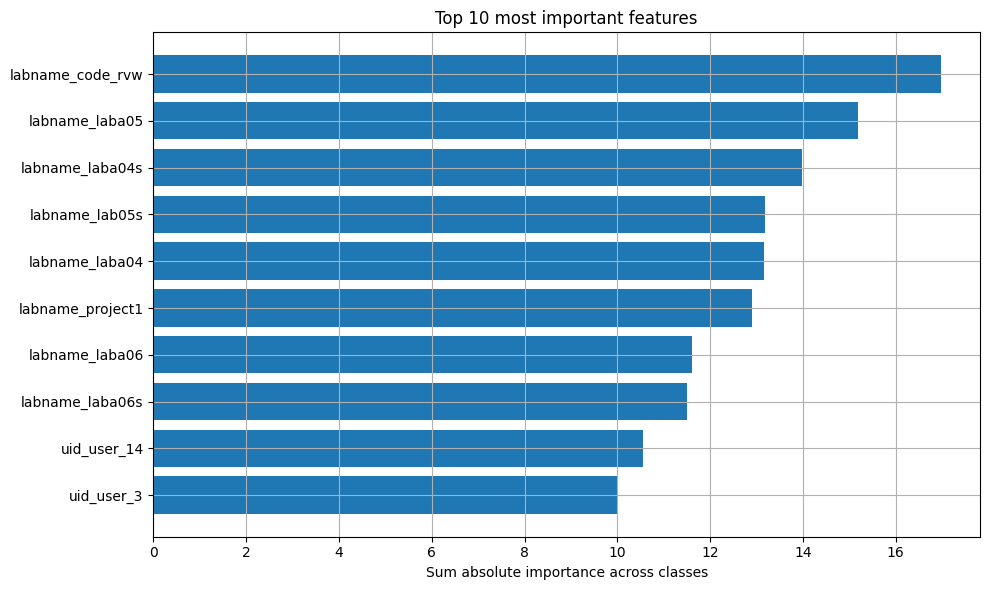

In [31]:
plot_top_features(ovr_coef_matrix, X_LR.columns, top_n=10, method='sum')

### b. SVC

1. Обучи модель `SVC`; для базовой модели используй параметры `kernel='linear'`, `probability=True`, `random_state=21`.
2. Попробуй разные ядра, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели с линейным ядром.*

*По умолчанию SVC использует стратегию “one vs one” для классификации, поэтому в `coef_` возвращает матрицу. Чтобы вычислить важность признака, нужно использовать [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) поверх SVC и просуммировать все индивидуальные значения важности признака для всех целевых классов.

In [32]:
svc_model = SVC(kernel='linear', probability=True, random_state=21)
svc_model.fit(X_LR, Y_LR)
ovr_model= OneVsRestClassifier(svc_model)
ovr_model.fit(X_LR, Y_LR)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(kernel='l...ndom_state=21)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001


In [33]:
svc_predict = svc_model.predict(X_LR)
accuracy_svc = accuracy_score(y_true, svc_predict)
print(f'Accuracy of SVC: {accuracy_svc }')

Accuracy of SVC: 0.702846975088968


In [34]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

for k in kernels:
    model = SVC(kernel=k, probability=True, random_state=21)
    model.fit(X_LR, Y_LR)
    preds = model.predict(X_LR)
    acc = accuracy_score(y_true, preds)
    print(f'kernel={k:<8} → accuracy = {acc }')

kernel=linear   → accuracy = 0.702846975088968
kernel=rbf      → accuracy = 0.8558718861209964
kernel=poly     → accuracy = 0.8594306049822064
kernel=sigmoid  → accuracy = 0.3997627520759193


In [35]:
for k in kernels:
    model = OneVsRestClassifier(SVC(kernel=k, probability=True, random_state=21))
    model.fit(X_LR, Y_LR)
    preds = model.predict(X_LR)
    acc = accuracy_score(y_true, preds)
    print(f'kernel={k:<8} → accuracy = {acc}')

kernel=linear   → accuracy = 0.6126927639383155
kernel=rbf      → accuracy = 0.8641755634638197
kernel=poly     → accuracy = 0.8653618030842231
kernel=sigmoid  → accuracy = 0.3499406880189798


In [36]:
coefs = np.vstack([est.coef_ for est in ovr_model.estimators_])

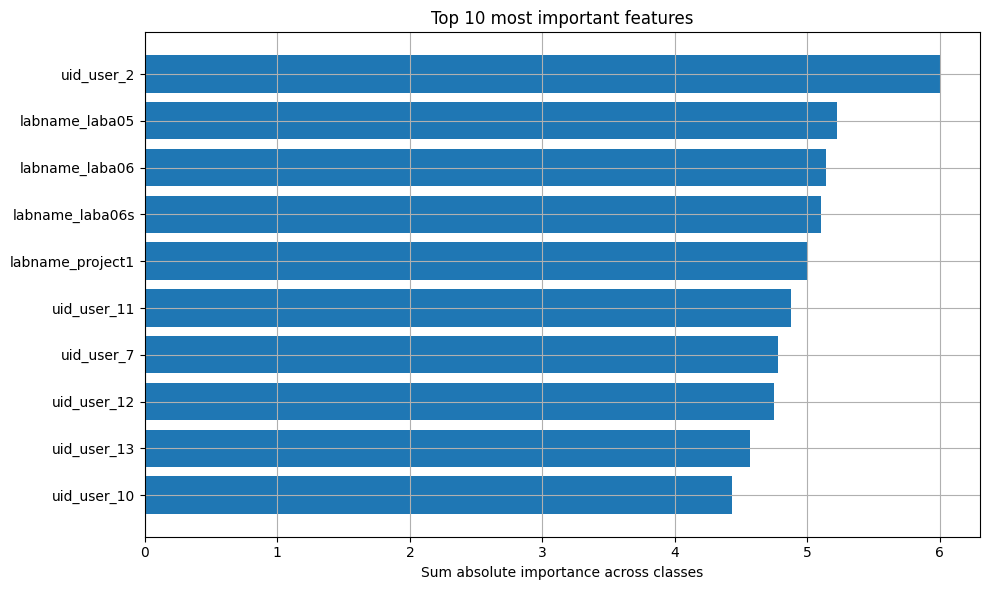

In [37]:
plot_top_features(coefs, X_LR.columns, top_n=10, method='sum')

### c. Дерево решений

1. Обучи `DecisionTreeClassifier`; для базовой модели используй `max_depth=4`, `random_state=21`.
2. Попробуй разные значения `max_depth`, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели, используя написанную функцию.

In [38]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=21)
tree_model.fit(X_LR, Y_LR)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",21
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [39]:
tree_preds = tree_model.predict(X_LR)
tree_acc = accuracy_score(y_true, tree_preds)
print(f'Accuracy of Decision Tree (depth=4): {tree_acc}')

Accuracy of Decision Tree (depth=4): 0.5516014234875445


In [40]:
depths = range(1, 11)
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=21)
    model.fit(X_LR, Y_LR)
    preds = model.predict(X_LR)
    acc = accuracy_score(y_true, preds)
    print(f'depth={d:<2} → accuracy = {acc}')

depth=1  → accuracy = 0.35765124555160144
depth=2  → accuracy = 0.4389086595492289
depth=3  → accuracy = 0.48991696322657174
depth=4  → accuracy = 0.5516014234875445
depth=5  → accuracy = 0.6109134045077106
depth=6  → accuracy = 0.6637010676156584
depth=7  → accuracy = 0.7064056939501779
depth=8  → accuracy = 0.7502965599051008
depth=9  → accuracy = 0.7846975088967971
depth=10 → accuracy = 0.8196915776986952


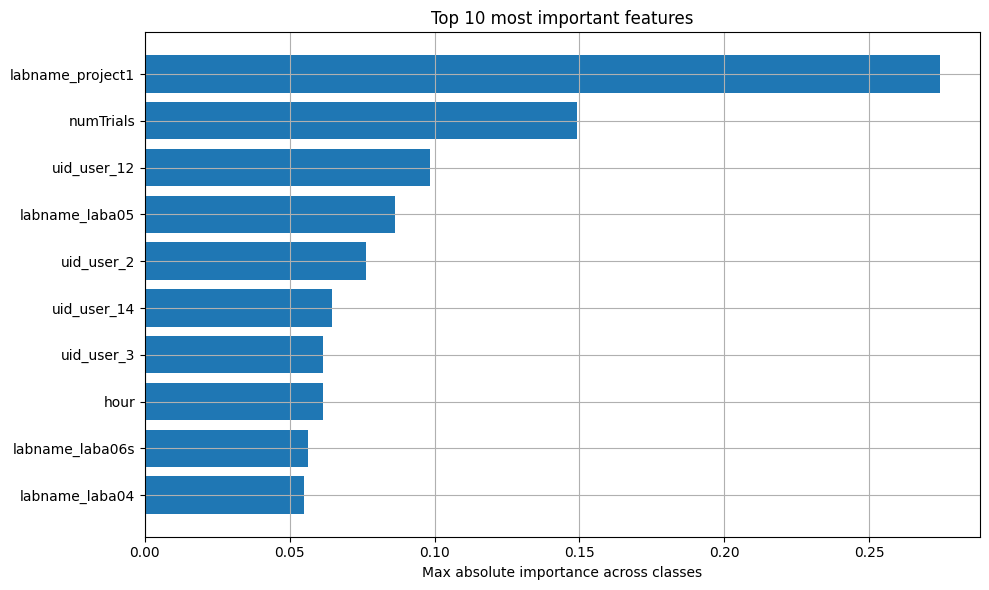

In [41]:
plot_top_features(tree_model.feature_importances_, X_LR.columns, top_n=10)

### d. Случайный лес

В реальной жизни лес состоит из множества деревьев. То же самое и в машинном обучении: случайный лес — это набор отдельных деревьев решений (подробнее см. документацию).

1. Обучи `RandomForestClassifier`; для базовой модели используй параметры `n_estimators=100`, `max_depth=25`, `random_state=21`.
2. Попробуй разные значения `max_depth` и `n_estimators`, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели, используя написанную функцию.

In [42]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf_model.fit(X_LR, Y_LR)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [43]:
rf_preds = rf_model.predict(X_LR)
rf_acc = accuracy_score(y_true, rf_preds)
print(f'Accuracy of Random Forest (baseline): {rf_acc}')

Accuracy of Random Forest (baseline): 1.0


In [44]:
estimators_list = [10, 50, 100, 150]
depth_list = [5, 10, 15, 20, 25]

for n in estimators_list:
    for d in depth_list:
        model = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=21)
        model.fit(X_LR, Y_LR)
        preds = model.predict(X_LR)
        acc = accuracy_score(y_true, preds)
        print(f'n_estimators={n:<3} | max_depth={d:<2} → accuracy = {acc}')

n_estimators=10  | max_depth=5  → accuracy = 0.6204033214709371
n_estimators=10  | max_depth=10 → accuracy = 0.833926453143535
n_estimators=10  | max_depth=15 → accuracy = 0.9572953736654805
n_estimators=10  | max_depth=20 → accuracy = 0.9822064056939501
n_estimators=10  | max_depth=25 → accuracy = 0.9940688018979834
n_estimators=50  | max_depth=5  → accuracy = 0.5990510083036773
n_estimators=50  | max_depth=10 → accuracy = 0.8819691577698695
n_estimators=50  | max_depth=15 → accuracy = 0.9750889679715302
n_estimators=50  | max_depth=20 → accuracy = 0.9958481613285883
n_estimators=50  | max_depth=25 → accuracy = 1.0
n_estimators=100 | max_depth=5  → accuracy = 0.599644128113879
n_estimators=100 | max_depth=10 → accuracy = 0.8879003558718861
n_estimators=100 | max_depth=15 → accuracy = 0.9786476868327402
n_estimators=100 | max_depth=20 → accuracy = 0.9970344009489917
n_estimators=100 | max_depth=25 → accuracy = 1.0
n_estimators=150 | max_depth=5  → accuracy = 0.5889679715302492
n_estima

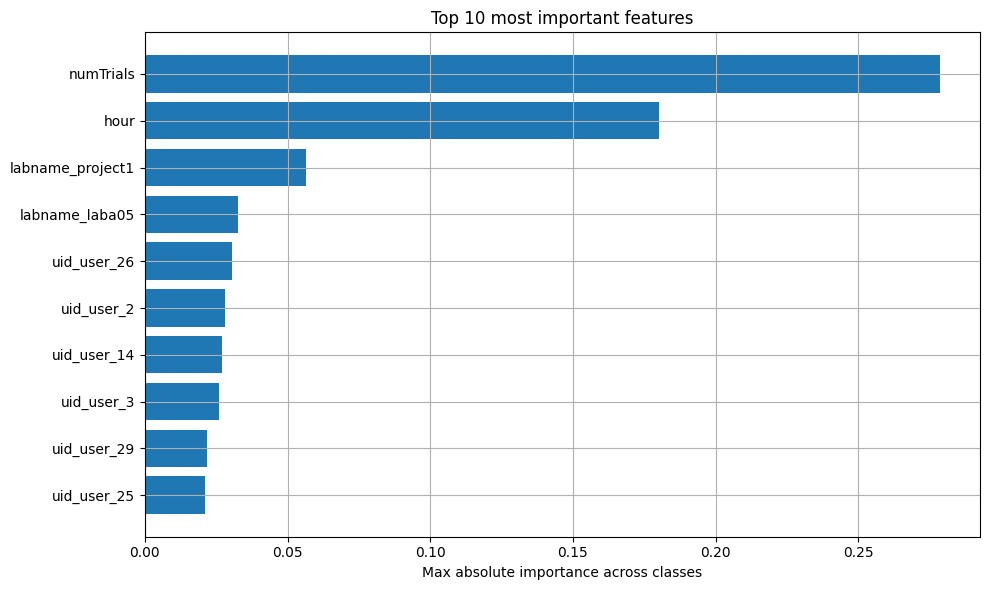

In [45]:
plot_top_features(rf_model.feature_importances_, X_LR.columns, top_n=10)